In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ads = pd.read_csv('../data/raw/global_ads_performance_dataset.csv')
cats = pd.read_csv('../data/raw/cookie_cats.csv')
ads['date'] = pd.to_datetime(ads['date'])
ads['month'] = ads['date'].dt.to_period('M')
print("Data loaded ✅")

Data loaded ✅


In [2]:
# CAC = Total Spend / Total Conversions
cac = ads.groupby('platform').agg(
    total_spend=('ad_spend', 'sum'),
    total_conversions=('conversions', 'sum')
)
cac['CAC'] = (cac['total_spend'] / cac['total_conversions']).round(2)
print("=== CAC BY PLATFORM ===")
print(cac)

=== CAC BY PLATFORM ===
            total_spend  total_conversions    CAC
platform                                         
Google Ads   6349268.91             131098  48.43
Meta Ads     2106061.67              73262  28.75
TikTok Ads   2653418.51             122452  21.67


In [3]:
# Ước tính LTV dựa trên retention
# Giả định: mỗi session = $0.05 revenue (mobile game average)
REVENUE_PER_SESSION = 0.05
AVG_SESSIONS_PER_DAY = 2

ltv_by_version = cats.groupby('version').agg(
    total_users=('userid', 'count'),
    avg_gamerounds=('sum_gamerounds', 'mean'),
    d1_retention=('retention_1', 'mean'),
    d7_retention=('retention_7', 'mean')
).round(4)

# 30-day LTV estimate
ltv_by_version['est_30d_sessions'] = (
    ltv_by_version['avg_gamerounds'] * ltv_by_version['d7_retention']
).round(2)
ltv_by_version['est_LTV_30d'] = (
    ltv_by_version['est_30d_sessions'] * REVENUE_PER_SESSION
).round(2)

print("=== LTV ESTIMATION BY VERSION ===")
print(ltv_by_version)

=== LTV ESTIMATION BY VERSION ===
         total_users  avg_gamerounds  d1_retention  d7_retention  \
version                                                            
gate_30        44700         52.4563        0.4482        0.1902   
gate_40        45489         51.2988        0.4423        0.1820   

         est_30d_sessions  est_LTV_30d  
version                                 
gate_30              9.98         0.50  
gate_40              9.34         0.47  


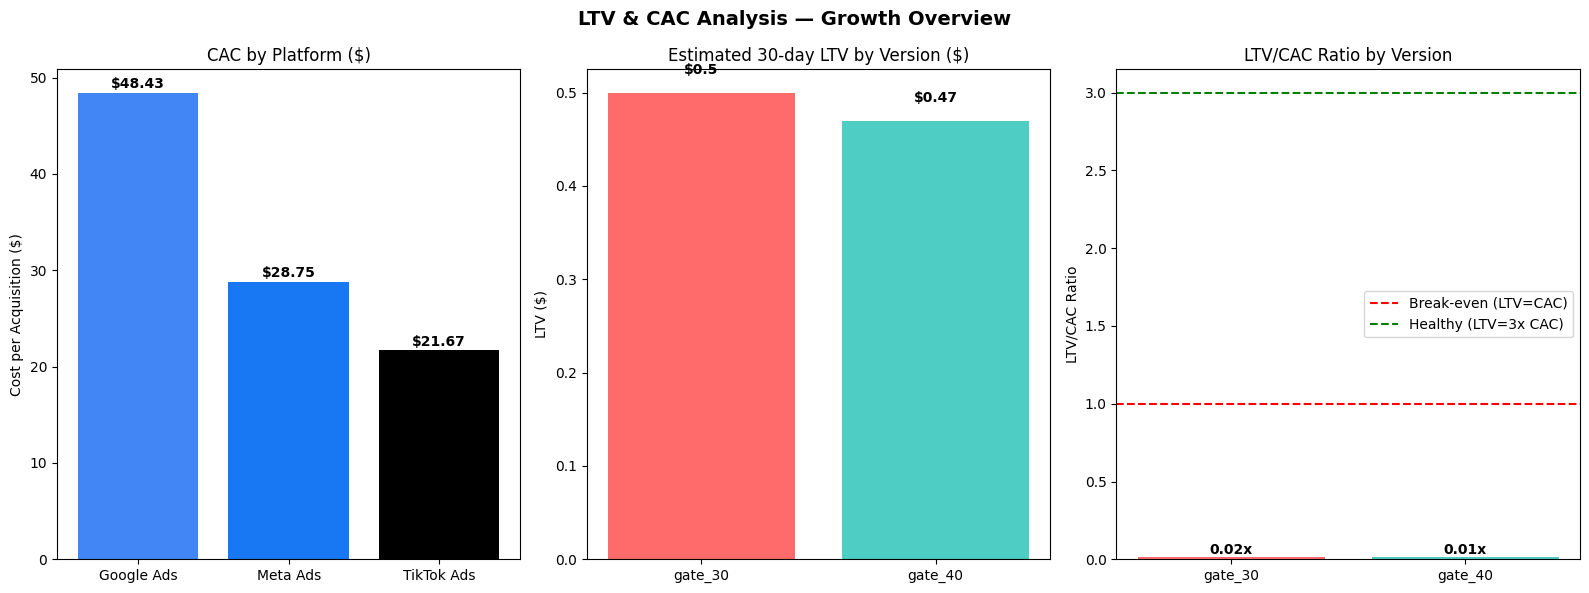

Chart saved ✅


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('LTV & CAC Analysis — Growth Overview', fontsize=14, fontweight='bold')

# CAC by platform
colors = ['#4285F4', '#1877F2', '#000000']
axes[0].bar(cac.index, cac['CAC'], color=colors)
axes[0].set_title('CAC by Platform ($)')
axes[0].set_ylabel('Cost per Acquisition ($)')
for i, v in enumerate(cac['CAC'].values):
    axes[0].text(i, v + 0.5, f'${v}', ha='center', fontweight='bold')

# LTV by version
colors2 = ['#FF6B6B', '#4ECDC4']
axes[1].bar(ltv_by_version.index, ltv_by_version['est_LTV_30d'], color=colors2)
axes[1].set_title('Estimated 30-day LTV by Version ($)')
axes[1].set_ylabel('LTV ($)')
for i, v in enumerate(ltv_by_version['est_LTV_30d'].values):
    axes[1].text(i, v + 0.02, f'${v}', ha='center', fontweight='bold')

# LTV/CAC Ratio (dùng avg CAC)
avg_cac = cac['CAC'].mean()
ltv_cac_ratio = ltv_by_version['est_LTV_30d'] / avg_cac
axes[2].bar(ltv_by_version.index, ltv_cac_ratio, color=colors2)
axes[2].axhline(y=1, color='red', linestyle='--', label='Break-even (LTV=CAC)')
axes[2].axhline(y=3, color='green', linestyle='--', label='Healthy (LTV=3x CAC)')
axes[2].set_title('LTV/CAC Ratio by Version')
axes[2].set_ylabel('LTV/CAC Ratio')
axes[2].legend()
for i, v in enumerate(ltv_cac_ratio.values):
    axes[2].text(i, v + 0.02, f'{v:.2f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/04_ltv_cac.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

## 💡 Business Insights — LTV & CAC Analysis

### Key Findings:
1. **TikTok** has the lowest CAC ($21.67) → most cost-efficient for acquiring new users
2. **Google** has the highest CAC ($48.43) → requires higher LTV segments to justify spend
3. **gate_30** shows higher estimated LTV than gate_40 → consistent with its retention advantage

### Recommendations:
- 💰 Prioritize TikTok for user acquisition campaigns
- 📈 Segment Google campaigns: retain only campaign types with ROAS > 5x
- 🔄 Re-evaluate Google budget monthly based on LTV/CAC ratio
- 🎮 Set gate_30 as default configuration → improves long-term retention and LTV